In [31]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import pandas as pd
import os

from numpy import pi

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    # Tamanhos de fonte
    "font.size": 12,          # tamanho base
    "axes.titlesize": 14,     # título do gráfico
    "axes.labelsize": 12,     # rótulos dos eixos
    "xtick.labelsize": 10,    # ticks eixo x
    "ytick.labelsize": 10,    # ticks eixo y
    "legend.fontsize": 10,    # legenda
})

# Parâmetros do sistema
Kp = np.float32(208.1420263238445)
ap = np.float32(6.734006734006734)

# Amplitude do degrau (Va)
Va = 5.5

# Constante para converter o valor 
# de RPM para graus
RPM_PARA_GRAUS = 6

# Parâmetros de simulação
Ts = 0.001
dt = Ts
Tfinal = 1.5
N = int(Tfinal / Ts)

# Simulação da saída em RPM

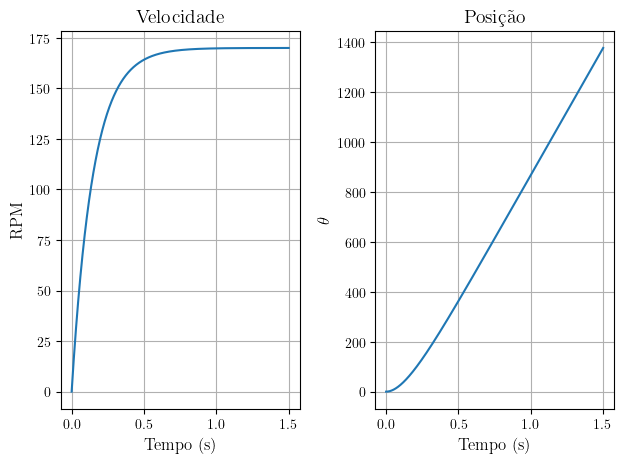

In [32]:
t = np.linspace(0, Tfinal, N)
y = np.zeros(N)
u = np.ones(N) * Va #V 
theta = np.zeros(N)

for k in range(N - 1):
    # velocidade
    y[k+1] = y[k] + Ts * (-ap * y[k] + Kp * u[k])

    theta[k+1] = theta[k] + Ts * (RPM_PARA_GRAUS * y[k])

plt.subplot(121)
plt.plot(t, y)
plt.xlabel('Tempo (s)')
plt.ylabel('RPM')
plt.title('Velocidade')
plt.grid()

plt.subplot(122)
plt.plot(t, theta)
plt.xlabel('Tempo (s)')
plt.ylabel(r'$\theta$')
plt.title('Posição')
plt.grid()

plt.tight_layout()

plt.savefig("respostadaFT.pdf")

plt.show()

# Simulando no Espaço de Estados

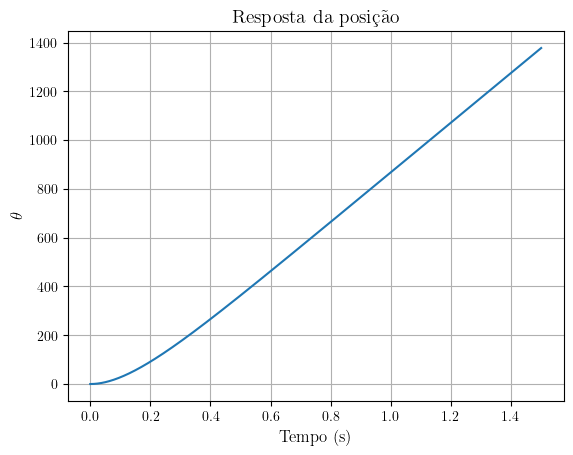

In [33]:
# Matrizes do sistema
A = np.array([[0, RPM_PARA_GRAUS],
              [0, -ap]])

B = np.array([[0],
              [Kp]])

C = np.array([[1, 0]])


# Inicialização
x = np.zeros((2, 1))  # [theta; omega]
y = np.zeros(N)
t = np.linspace(0, Tfinal, N)

u = Va

# Simulação Euler
for k in range(N):
    y[k] = (C @ x)[0, 0]
    x = x + Ts * (A @ x + B * u)

# Plot
plt.plot(t, y)
plt.xlabel('Tempo (s)')
plt.ylabel(r'$\theta$')
plt.title('Resposta da posição')
plt.grid()

plt.savefig("resposNoEspacoDeEstadosPosicao.pdf")

plt.show()

# Ganho de realimentação 

## Parâmetros do controlador

In [34]:
# Overshoot
Mp = 5 / 100

# Tempo de acomodação de 2%
ts2 = 0.4

# Coeficiente de amortecimento
zeta = np.sqrt((np.log(Mp)**2) / (np.pi**2 + np.log(Mp)**2))

# Frequencia natural do sistema
wm = 4 / (ts2*zeta)

print(f'Mp = {Mp}')
print(f'ts (2%) = {ts2}')
print(f'Zeta = {zeta}')
print(f'wm (rad/s) = {wm}')

real = zeta*wm
imag = wm*np.sqrt(1-zeta**2)

polos = np.array([-real+imag*1j, -real-imag*1j, -real*4])

print(f'polos = {polos}')

Mp = 0.05
ts (2%) = 0.4
Zeta = 0.6901067305598216
wm (rad/s) = 14.490512202203703
polos = [-10.+10.48689391j -10.-10.48689391j -40. +0.j        ]


## Ganhos de realimentação usando Ackerman

In [35]:
# ===============================
#  Novo Sistema
# ===============================

# Matriz de Controlabilidade
U = np.concatenate((B, A @ B), axis=1)
rank_U = np.linalg.matrix_rank(U)
print()
print("\nMatriz de Controlabilidade U:\n", U)
print()
print("Posto da Matriz de Controlabilidade:", rank_U)
print()

# Expandindo as matrizes para incluir o integrador
# e o estado erro
Ahat = np.concatenate((A, np.zeros((A.shape[0],1))), axis=1)
temp = np.concatenate((-C, np.array([[0]])), axis=1)
Ahat = np.concatenate((Ahat, temp), axis=0)
Bhat = np.concatenate((B, np.array([[0]])), axis=0)

del temp

# Ganho de realimentatacao e de integracao
Kvect = signal.place_poles(Ahat, Bhat, polos).gain_matrix

KI = np.copy(Kvect[0,2])
print("KI:\n", KI)

K = np.copy(Kvect[0,0:2])
print("K:\n", K)


# Sistema aumentado acrecentado do 
# estado erro e ganho dos estados
A00 = A - (B * K)
A01 = B * -KI
A10 = -C
A11 = np.array([[0]])
    
Af = np.concatenate((A00, A01), axis=1)
temp = np.concatenate((A10, A11), axis=1)
Af = np.concatenate((Af, temp), axis=0)

print(f'autovalores de Af: \n{np.linalg.eigvals(Af)}')

del temp



Matriz de Controlabilidade U:
 [[    0.          1248.85217285]
 [  208.14202881 -1401.62985437]]

Posto da Matriz de Controlabilidade: 2

KI:
 -6.725373857588525
K:
 [0.80872257 0.25591176]
autovalores de Af: 
[-40. +0.j         -10.+10.48689391j -10.-10.48689391j]


# Simulação com o seguidor de referência

## SEM saturação

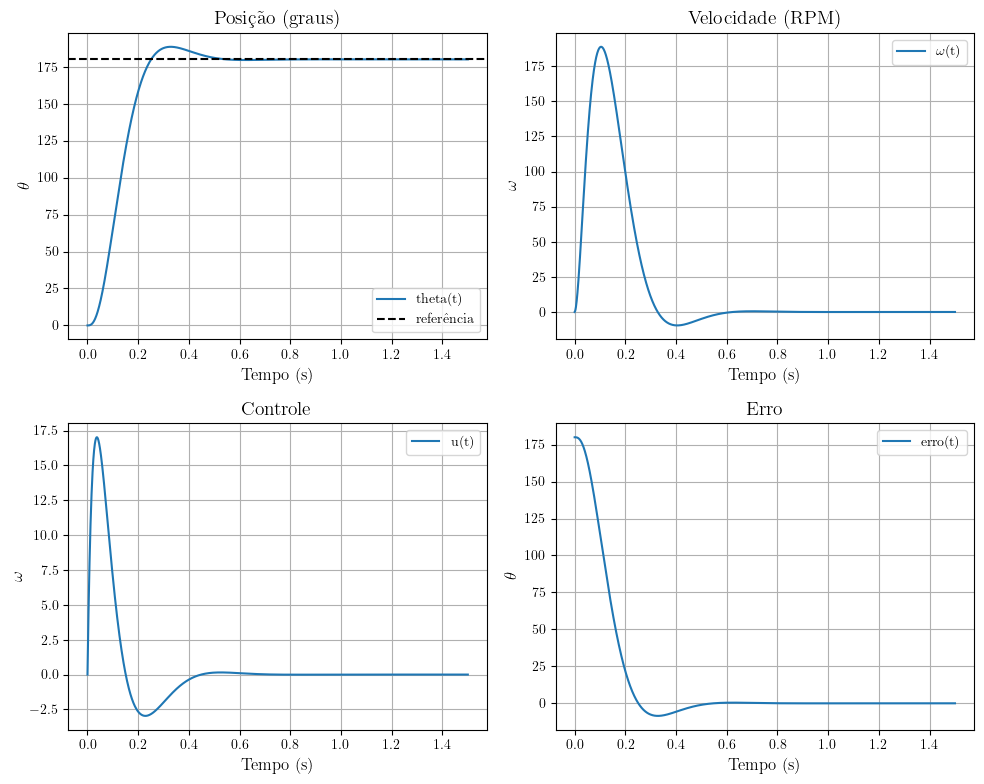

In [36]:
def saturate(u, u_min, u_max):
    return max(min(u, u_max), u_min)

def apply_deadzone_asym(u, dz_pos, dz_neg):
    if u > 0:
        return 0.0 if u < dz_pos else u
    elif u < 0:
        return 0.0 if abs(u) < dz_neg else u
    else:
        return 0.0

t = np.linspace(0, Tfinal, N)

# Referência em graus (corrigido)
r = 180.0

# Estados: [theta, omega, erro_integral]
x = np.array([[0.0],
              [0.0],
              [0.0]])

x_history = np.zeros((3, N))
u_history = np.zeros(N)
y = np.zeros(N)

Kvect = Kvect.reshape(-1,1)

# Sistema aumentado
Aa = np.block([
    [A, np.zeros((2, 1))],
    [-C, np.array([[0]])]
])

Bb = np.vstack((B, [[0]]))
Cc = np.hstack((C, [[0]]))

# Simulação
for i in range(N):

    # Saída (posição)
    y[i] = (Cc @ x)[0,0]

    # Controle
    u = (-Kvect.T @ x).item()

    #u = apply_deadzone_asym(u, 1.5, 1.5)
    #u = saturate(u, -5.5, 5.5)

    u_history[i] = u

    # Dinâmica
    x_dot = Aa @ x + Bb * u

    # Integrador do erro
    x_dot[2,0] = r - y[i]

    # Euler
    x = x + Ts * x_dot

    x_history[:, i] = x[:,0]

# Extração dos estados (corrigido)
theta = x_history[0, :]   # posição (graus)
omega = x_history[1, :]   # velocidade (RPM)
erro = r - theta

plt.figure(figsize=(10, 8))

# Posição
plt.subplot(2, 2, 1)
plt.plot(t, theta, label='theta(t)')
plt.axhline(r, linestyle='--', label='referência', color='black')
plt.title("Posição (graus)")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\theta$')
plt.grid()
plt.legend()

# Velocidade
plt.subplot(2, 2, 2)
plt.plot(t, omega, label=r'$\omega$(t)')
plt.title("Velocidade (RPM)")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\omega$')
plt.grid()
plt.legend()

# Controle
plt.subplot(2, 2, 3)
plt.plot(t, u_history, label='u(t)')
plt.title("Controle")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\omega$')
plt.grid()
plt.legend()

# Erro
plt.subplot(2, 2, 4)
plt.plot(t, erro, label='erro(t)')
plt.title("Erro")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\theta$')
plt.grid()
plt.legend()

plt.tight_layout()

plt.savefig("RespostaSEMSaturacao.pdf")

plt.show()

erroSEMSaturacao = np.copy(erro)

## COM Saturação

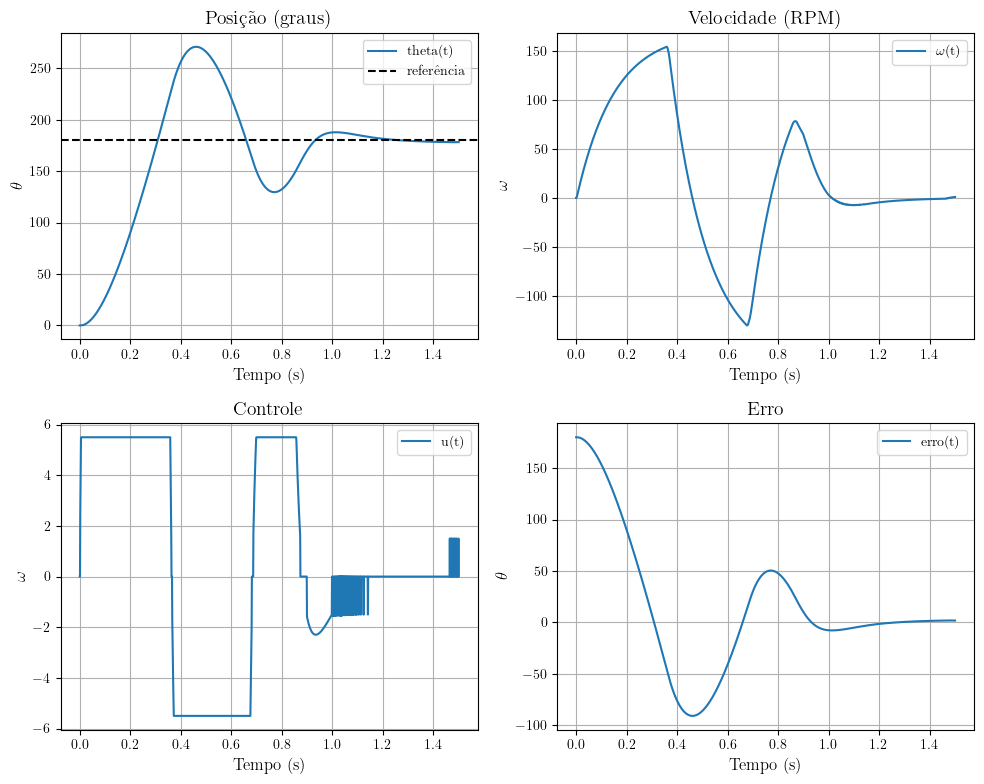

In [37]:
def saturate(u, u_min, u_max):
    return max(min(u, u_max), u_min)

def apply_deadzone_asym(u, dz_pos, dz_neg):
    if u > 0:
        return 0.0 if u < dz_pos else u
    elif u < 0:
        return 0.0 if abs(u) < dz_neg else u
    else:
        return 0.0

t = np.linspace(0, Tfinal, N)

# Referência em graus (corrigido)
r = 180.0

# Estados: [theta, omega, erro_integral]
x = np.array([[0.0],
              [0.0],
              [0.0]])

x_history = np.zeros((3, N))
u_history = np.zeros(N)
y = np.zeros(N)

Kvect = Kvect.reshape(-1,1)

# Sistema aumentado
Aa = np.block([
    [A, np.zeros((2, 1))],
    [-C, np.array([[0]])]
])

Bb = np.vstack((B, [[0]]))
Cc = np.hstack((C, [[0]]))

# Simulação
for i in range(N):

    # Saída (posição)
    y[i] = (Cc @ x)[0,0]

    # Controle
    u = (-Kvect.T @ x).item()


    u = apply_deadzone_asym(u, 1.5, 1.5)
    u = saturate(u, -Va, Va)

    u_history[i] = u

    # Dinâmica
    x_dot = Aa @ x + Bb * u

    # Integrador do erro
    x_dot[2,0] = r - y[i]

    # Euler
    x = x + Ts * x_dot

    x_history[:, i] = x[:,0]

# Extração dos estados (corrigido)
theta = x_history[0, :]   # posição (graus)
omega = x_history[1, :]   # velocidade (RPM)
erro = r - theta

plt.figure(figsize=(10, 8))

# Posição
plt.subplot(2, 2, 1)
plt.plot(t, theta, label='theta(t)')
plt.axhline(r, linestyle='--', label='referência', color='black')
plt.title("Posição (graus)")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\theta$')
plt.grid()
plt.legend()

# Velocidade
plt.subplot(2, 2, 2)
plt.plot(t, omega, label=r'$\omega$(t)')
plt.title("Velocidade (RPM)")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\omega$')
plt.grid()
plt.legend()

# Controle
plt.subplot(2, 2, 3)
plt.plot(t, u_history, label='u(t)')
plt.title("Controle")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\omega$')
plt.grid()
plt.legend()

# Erro
plt.subplot(2, 2, 4)
plt.plot(t, erro, label='erro(t)')
plt.title("Erro")
plt.xlabel("Tempo (s)")
plt.ylabel(r'$\theta$')
plt.grid()
plt.legend()

plt.tight_layout()

plt.savefig("RespostaSEMSaturacao.pdf")

plt.show()

erroCOMSaturacao = np.copy(erro)

# Critérios de erro

## ISE

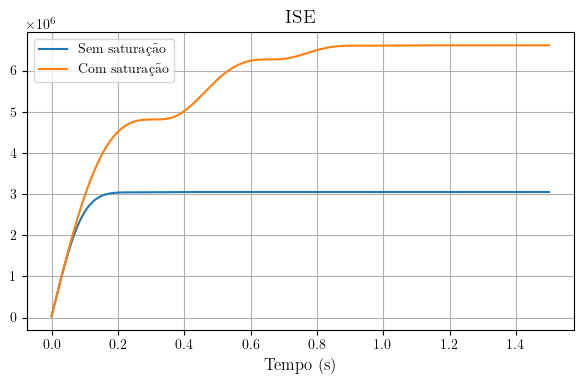

In [38]:
ISE_sem_saturacao = np.cumsum(erroSEMSaturacao**2)
ISE_com_saturacao = np.cumsum(erroCOMSaturacao**2)

plt.figure(figsize=(6,4))

# plt.subplot(1,2,1)
# plt.plot(t, erroSEMSaturacao, label='Sem saturação')
# plt.plot(t, erroCOMSaturacao, label='Com saturação')
# plt.title("Erro")
# plt.xlabel("Tempo (s)")
# plt.grid()
# plt.legend()

# plt.subplot(1,2,2)
plt.plot(t, ISE_sem_saturacao, label='Sem saturação')
plt.plot(t, ISE_com_saturacao, label='Com saturação')
plt.title("ISE")
plt.xlabel("Tempo (s)")
plt.grid()
plt.legend()

plt.tight_layout()

plt.savefig("ISE.pdf")

plt.show()

## ITSE

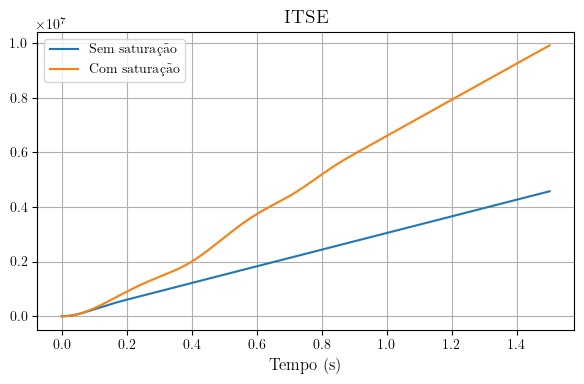

In [39]:
ITSE_sem_saturacao = np.cumsum(erroSEMSaturacao**2) * t
ITSE_com_saturacao = np.cumsum(erroCOMSaturacao**2) * t

plt.figure(figsize=(6,4))

# plt.subplot(1,2,1)
# plt.plot(t, erroSEMSaturacao, label='Sem saturação')
# plt.plot(t, erroCOMSaturacao, label='Com saturação')
# plt.title("Erro")
# plt.xlabel("Tempo (s)")
# plt.grid()
# plt.legend()

# plt.subplot(1,2,2)
plt.plot(t, ITSE_sem_saturacao, label='Sem saturação')
plt.plot(t, ITSE_com_saturacao, label='Com saturação')
plt.title("ITSE")
plt.xlabel("Tempo (s)")
plt.grid()
plt.legend()

plt.tight_layout()

plt.savefig("ITSE.pdf")

plt.show()

## IAE

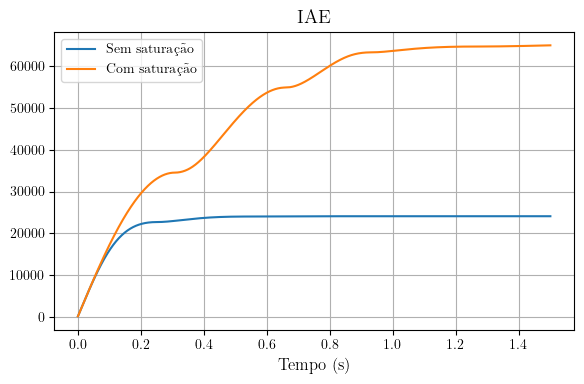

In [40]:
IAE_sem_saturacao = np.cumsum(np.abs(erroSEMSaturacao))
IAE_com_saturacao = np.cumsum(np.abs(erroCOMSaturacao))

plt.figure(figsize=(6,4))

# plt.subplot(1,2,1)
# plt.plot(t, erroSEMSaturacao, label='Sem saturação')
# plt.plot(t, erroCOMSaturacao, label='Com saturação')
# plt.title("Erro")
# plt.xlabel("Tempo (s)")
# plt.grid()
# plt.legend()

# plt.subplot(1,2,2)
plt.plot(t, IAE_sem_saturacao, label='Sem saturação')
plt.plot(t, IAE_com_saturacao, label='Com saturação')
plt.title("IAE")
plt.xlabel("Tempo (s)")
plt.grid()
plt.legend()

plt.tight_layout()

plt.savefig("IAE.pdf")

plt.show()

## ITAE

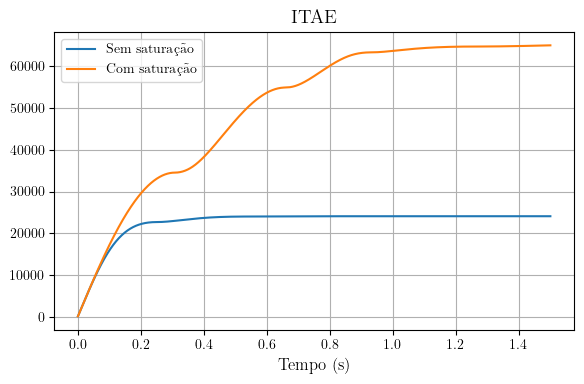

In [41]:
ITAE_sem_saturacao = np.cumsum(np.abs(erroSEMSaturacao)) * t
ITAE_com_saturacao = np.cumsum(np.abs(erroCOMSaturacao)) * t

plt.figure(figsize=(6,4))

# plt.subplot(1,2,1)
# plt.plot(t, erroSEMSaturacao, label='Sem saturação')
# plt.plot(t, erroCOMSaturacao, label='Com saturação')
# plt.title("Erro")
# plt.xlabel("Tempo (s)")
# plt.grid()
# plt.legend()

# plt.subplot(1,2,2)
plt.plot(t, IAE_sem_saturacao, label='Sem saturação')
plt.plot(t, IAE_com_saturacao, label='Com saturação')
plt.title("ITAE")
plt.xlabel("Tempo (s)")
plt.grid()
plt.legend()

plt.tight_layout()

plt.savefig("ITAE.pdf")

plt.show()